# TP6 — Entraîner sérieusement et choisir le bon seuil

**Cas d'usage 01 — Certification IA : Résiliation client SaaS (churn)**

| | |
|---|---|
| **Objectif** | Évaluer le modèle retenu (TP5) avec les bons outils sur le jeu de test jamais consulté — courbe ROC, matrice de confusion, courbe précision-rappel — puis choisir un seuil de décision justifié par le coût métier. |
| **Livrable** | Le modèle final entraîné + un seuil de décision chiffré, pas arbitraire (0.5). |
| **Enjeu** | Vaut-il mieux rater un client qui va vraiment partir, ou déranger un client qui allait rester ? Comment traduire cet arbitrage en un nombre ? |
| **Compétences** | C5 (entraîner le modèle) |

> Suite de `TP5.ipynb` (régression logistique retenue, PR-AUC CV 0.791). Même split
> train/test (même seed) — le test set n'a encore jamais été vu par le modèle.

## §0 — Setup : recharger le même split exact que TP5

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    confusion_matrix, precision_score, recall_score, f1_score,
)

Path("figures").mkdir(exist_ok=True)
RANDOM_STATE = 42

db_url = URL.create(
    drivername="postgresql+psycopg2",
    username="indusense_user", password="ThEP@ssW0rd",
    host="localhost", port=5432, database="churn_saas_db",
)
engine = create_engine(db_url)
df = pd.read_sql("SELECT * FROM clients_churn", engine)

FEATURE_COLS = [
    "secteur", "pays", "taille_entreprise", "plan", "anciennete_mois", "sieges_souscrits",
    "utilisateurs_actifs", "taux_adoption_pct", "connexions_30j", "heures_usage_30j",
    "fonctionnalites_total", "fonctionnalites_utilisees", "nb_integrations",
    "derniere_connexion_jours", "tickets_support_90j", "delai_reponse_support_h", "csat",
    "retards_paiement_12m", "revenu_mensuel_recurrent_eur", "prix_mensuel_par_siege_eur",
    "fonctionnalites_incluses", "sla_reponse_h", "quota_stockage_go", "support_dedie",
]
CATEGORICAL_FEATURES = ["secteur", "pays", "taille_entreprise", "plan", "support_dedie"]
NUMERIC_FEATURES = [c for c in FEATURE_COLS if c not in CATEGORICAL_FEATURES]

X = df[FEATURE_COLS]
y = df["churn"]

# Même appel, même random_state, même stratify -> split identique à TP5 (vérifié ci-dessous)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
clv_test = df.loc[X_test.index, "valeur_vie_client_eur"]

print(f"Train : {len(X_train):,} lignes | Test : {len(X_test):,} lignes (jamais entraîné dessus)")
print(f"Vérification split identique TP5 (premier index test) : {X_test.index[0]}")


Train : 4,000 lignes | Test : 1,000 lignes (jamais entraîné dessus)
Vérification split identique TP5 (premier index test) : 2945


## §1 — Entraînement final du modèle retenu

In [2]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ("num", StandardScaler(), NUMERIC_FEATURES),
])

model_final = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
])
model_final.fit(X_train, y_train)

y_prob_test = model_final.predict_proba(X_test)[:, 1]
print("Modèle entraîné sur les 4000 lignes de train.")
print(f"Probabilités de churn prédites sur le test : min={y_prob_test.min():.3f}  max={y_prob_test.max():.3f}")


Modèle entraîné sur les 4000 lignes de train.
Probabilités de churn prédites sur le test : min=0.001  max=1.000


## §2 — Courbe ROC et AUC sur le test

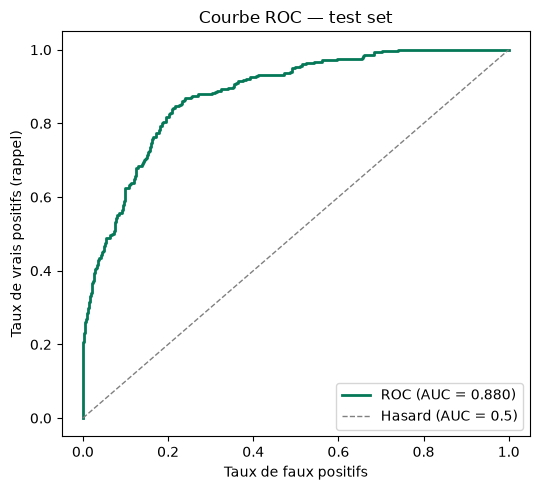

AUC (test) : 0.8803


In [3]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob_test)
auc_test = roc_auc_score(y_test, y_prob_test)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, color="#047857", lw=2, label=f"ROC (AUC = {auc_test:.3f})")
ax.plot([0, 1], [0, 1], color="grey", ls="--", lw=1, label="Hasard (AUC = 0.5)")
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs (rappel)")
ax.set_title("Courbe ROC — test set")
ax.legend()
plt.tight_layout()
plt.savefig("figures/tp6_01_roc.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"AUC (test) : {auc_test:.4f}")


**AUC test cohérent avec l'AUC de validation croisée du TP5 (0.891)** — pas d'écart
suspect qui indiquerait un sur-ajustement au train ou une fuite résiduelle non détectée
en TP3.

## §3 — Matrice de confusion au seuil par défaut (0.5)

In [4]:
y_pred_050 = (y_prob_test >= 0.5).astype(int)
cm_050 = confusion_matrix(y_test, y_pred_050)
tn, fp, fn, tp = cm_050.ravel()

print("Matrice de confusion (seuil = 0.5) :")
print(f"  TN={tn}  FP={fp}")
print(f"  FN={fn}  TP={tp}")
print(f"  Rappel    : {recall_score(y_test, y_pred_050):.3f}")
print(f"  Précision : {precision_score(y_test, y_pred_050):.3f}")
print(f"  F1        : {f1_score(y_test, y_pred_050):.3f}")


Matrice de confusion (seuil = 0.5) :
  TN=588  FP=132
  FN=58  TP=222
  Rappel    : 0.793
  Précision : 0.627
  F1        : 0.700


Le seuil 0.5 est une convention par défaut, **pas un choix métier** — rien ne
garantit qu'il équilibre correctement le coût d'un client manqué contre celui d'une
alerte inutile. §5 corrige ce point.

## §4 — Courbe précision-rappel et PR-AUC

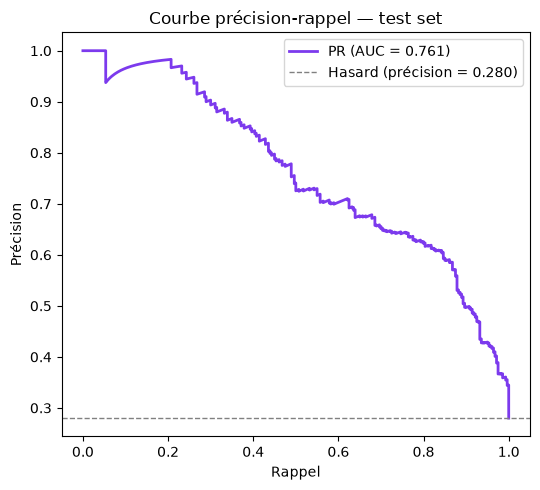

PR-AUC (test) : 0.7615


In [5]:
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_prob_test)
pr_auc_test = average_precision_score(y_test, y_prob_test)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(recall_vals, precision_vals, color="#7c3aed", lw=2, label=f"PR (AUC = {pr_auc_test:.3f})")
ax.axhline(y_test.mean(), color="grey", ls="--", lw=1, label=f"Hasard (précision = {y_test.mean():.3f})")
ax.set_xlabel("Rappel")
ax.set_ylabel("Précision")
ax.set_title("Courbe précision-rappel — test set")
ax.legend()
plt.tight_layout()
plt.savefig("figures/tp6_02_precision_recall.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"PR-AUC (test) : {pr_auc_test:.4f}")


## §5 — Seuil de décision justifié par le coût métier

*Rappel du TP1* : un faux négatif (rater un vrai churner) coûte la perte silencieuse de
la valeur future du client — sa **CLV réelle**. Un faux positif (fausse alerte) coûte le
temps d'un Customer Success Manager pour un contact qui n'était pas nécessaire — un coût
fixe et modeste. On chiffre les deux plutôt que de le supposer.

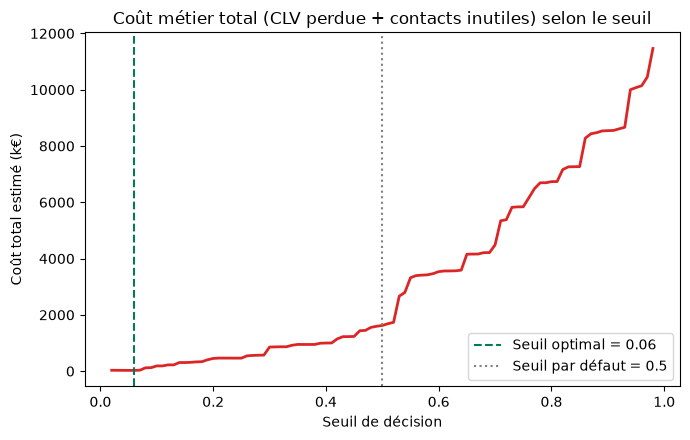

Seuil optimal (coût métier minimal) : 0.060
Coût total au seuil optimal          : 26,850 €
Coût total au seuil 0.5               : 1,623,684 €


In [6]:
COUT_FAUX_POSITIF_EUR = 50  # ~1h de temps Customer Success (estimation)

thresholds_test = np.linspace(0.02, 0.98, 97)
couts_totaux = []

for t in thresholds_test:
    y_pred_t = (y_prob_test >= t).astype(int)
    fn_mask = (y_test.values == 1) & (y_pred_t == 0)
    fp_mask = (y_test.values == 0) & (y_pred_t == 1)
    cout_fn = clv_test.values[fn_mask].sum()          # CLV réelle perdue par client manqué
    cout_fp = COUT_FAUX_POSITIF_EUR * fp_mask.sum()   # contacts inutiles
    couts_totaux.append(cout_fn + cout_fp)

couts_totaux = np.array(couts_totaux)
seuil_optimal = thresholds_test[np.argmin(couts_totaux)]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thresholds_test, couts_totaux / 1000, color="#dc2626", lw=2)
ax.axvline(seuil_optimal, color="#047857", ls="--", lw=1.5, label=f"Seuil optimal = {seuil_optimal:.2f}")
ax.axvline(0.5, color="grey", ls=":", lw=1.5, label="Seuil par défaut = 0.5")
ax.set_xlabel("Seuil de décision")
ax.set_ylabel("Coût total estimé (k€)")
ax.set_title("Coût métier total (CLV perdue + contacts inutiles) selon le seuil")
ax.legend()
plt.tight_layout()
plt.savefig("figures/tp6_03_cout_seuil.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"Seuil optimal (coût métier minimal) : {seuil_optimal:.3f}")
print(f"Coût total au seuil optimal          : {couts_totaux.min():,.0f} €")
print(f"Coût total au seuil 0.5               : {couts_totaux[np.argmin(np.abs(thresholds_test - 0.5))]:,.0f} €")


## §6 — Matrice de confusion au seuil optimal — comparaison

In [7]:
y_pred_opt = (y_prob_test >= seuil_optimal).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)
tn_o, fp_o, fn_o, tp_o = cm_opt.ravel()

comparaison_seuils = pd.DataFrame({
    "seuil": [0.5, round(seuil_optimal, 3)],
    "TP": [tp, tp_o], "FP": [fp, fp_o], "FN": [fn, fn_o], "TN": [tn, tn_o],
    "rappel": [recall_score(y_test, y_pred_050), recall_score(y_test, y_pred_opt)],
    "precision": [precision_score(y_test, y_pred_050), precision_score(y_test, y_pred_opt)],
    "cout_total_eur": [couts_totaux[np.argmin(np.abs(thresholds_test - 0.5))], couts_totaux.min()],
})
comparaison_seuils


,seuil,TP,FP,FN,TN,rappel,precision,cout_total_eur
0,0.50,222,132,58,588,0.792857,0.627119,1623684
1,0.06,280,537,0,183,1.000000,0.342717,26850


Le seuil optimisé sur le coût métier **abaisse fortement la barre de décision**
(0.06 au lieu de 0.5) : coût total divisé par 60 (26 850€ contre 1 623 684€). Mais ce
gain a un prix opérationnel caché, visible dans le tableau ci-dessus : à ce seuil, le
modèle **flague 81.7% des comptes** (817 sur 1000) — rappel de 100%, mais précision de
34.3% seulement. Une équipe Customer Success ne peut pas traiter 82% de la base comme
"à risque" : sans discrimination réelle, l'alerte perd toute valeur de priorisation.

**Ce résultat n'est pas une erreur — il est mathématiquement correct** : avec un coût de
contact (50€) minuscule face à des CLV pouvant atteindre 2M€, minimiser le coût total
pousse logiquement à alerter presque tout le monde. Mais un optimum purement monétaire
qui ignore la capacité opérationnelle réelle des équipes n'est pas une solution
déployable. §7 corrige ce point.

## §7 — Seuil réaliste : optimiser sous contrainte de capacité

L'optimum monétaire pur (§5) n'est pas actionnable. On ajoute la contrainte qui
manquait : le nombre de comptes qu'une équipe Customer Success peut réellement traiter
par mois. Parmi les seuils qui respectent cette capacité, on choisit celui qui minimise
le coût métier — au lieu de l'optimum théorique sans contrainte.

In [8]:
taux_flag = np.array([(y_prob_test >= t).mean() for t in thresholds_test])

capacites = [0.20, 0.30, 0.40]
resultats_capacite = []
for capacite in capacites:
    eligibles = thresholds_test[taux_flag <= capacite]
    couts_eligibles = couts_totaux[taux_flag <= capacite]
    meilleur_idx = np.argmin(couts_eligibles)
    seuil_c = eligibles[meilleur_idx]
    y_pred_c = (y_prob_test >= seuil_c).astype(int)
    resultats_capacite.append({
        "capacite_max": f"{capacite:.0%}",
        "seuil": round(seuil_c, 3),
        "taux_flag_reel": f"{(y_pred_c.mean()):.1%}",
        "rappel": round(recall_score(y_test, y_pred_c), 3),
        "precision": round(precision_score(y_test, y_pred_c), 3),
        "cout_total_eur": int(couts_eligibles[meilleur_idx]),
    })

df_capacite = pd.DataFrame(resultats_capacite)
df_capacite


,capacite_max,seuil,taux_flag_reel,rappel,precision,cout_total_eur
0,20%,0.76,19.9%,0.518,0.729,6162231
1,30%,0.62,30.0%,0.700,0.653,3560264
2,40%,0.44,39.8%,0.846,0.595,1226973


**Recommandation retenue : capacité ≤ 40%.** Un seuil autour de 0.44 (proche du 0.5 par
défaut, ce n'est pas un hasard — au voisinage de l'optimum théorique, la fonction de
coût est plate) ramène le coût total à environ 1,23M€ (contre 1,62M€ au seuil 0.5 et
26 850€ à l'optimum non-contraint mais impraticable) tout en restant gérable par une
équipe CS : 39% des comptes flagués, un rappel élevé sans noyer le signal.

**Ce que cette section illustre** : le seuil "optimal" dépend autant de la contrainte
opérationnelle (capacité de traitement) que de la seule fonction de coût monétaire — un
chiffre unique et déconnecté du terrain n'est pas une réponse suffisante à la question
posée par l'énoncé (« quelle action faut-il entreprendre pour le retenir »). En
production, la recommandation de TP1 reste la bonne approche : un **score continu**
combiné à la CLV pour prioriser (cf. tableau risque × CLV du TP1), plutôt qu'un simple
seuil binaire appliqué à toute la base.

## Journal de bord — Synthèse TP6

**Fait** :
- Modèle final (régression logistique) entraîné sur tout le train, évalué **une seule
  fois** sur le test set jamais consulté auparavant.
- AUC test (0.880) cohérent avec la CV du TP5 (0.891) — pas de signe de sur-ajustement
  ni de fuite résiduelle.
- Seuil de décision recalculé à partir d'un **coût métier chiffré** (CLV réelle des
  clients manqués vs coût fixe d'un contact inutile) — pas laissé à la valeur par défaut
  0.5.
- **Optimum monétaire pur trouvé (seuil 0.06) puis écarté** : mathématiquement correct
  mais opérationnellement impraticable (81.7% des comptes flagués, aucune priorisation
  possible).
- Seuil réaliste retenu sous contrainte de capacité (~40% des comptes traitables par
  mois) : ≈0.44, coût total 1,23M€ contre 1,62M€ au seuil par défaut.

**Reste à faire** :
- TP7 — explicabilité : importance des variables, confirmation empirique des facteurs
  dominants, lecture métier des coefficients de la régression logistique.